In [2]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
df = pd.read_csv('diabetes.csv')
df[:8]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [46]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.shape

(768, 9)

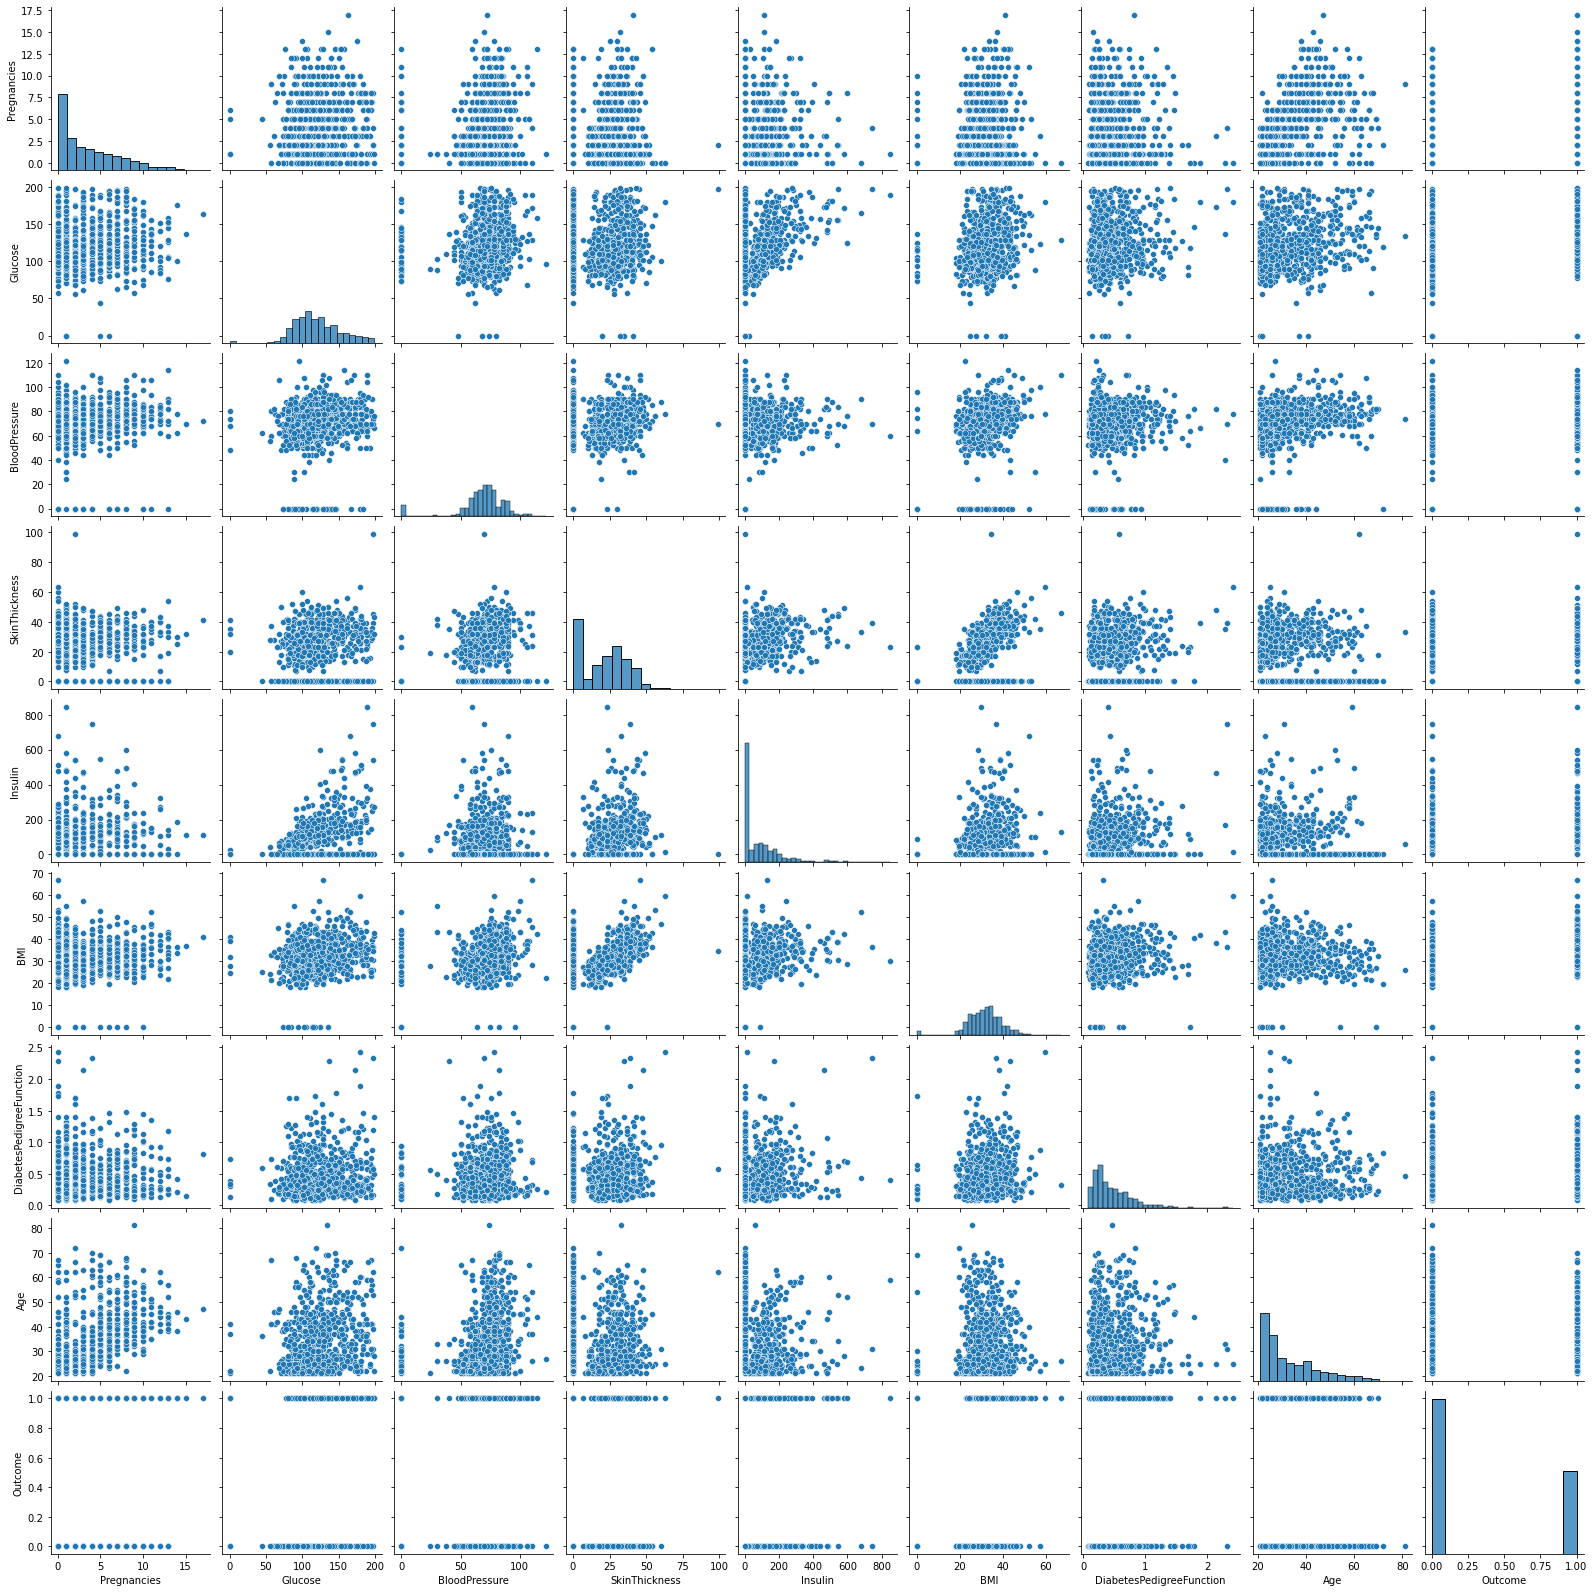

In [6]:
sns.pairplot(df)

<AxesSubplot:>

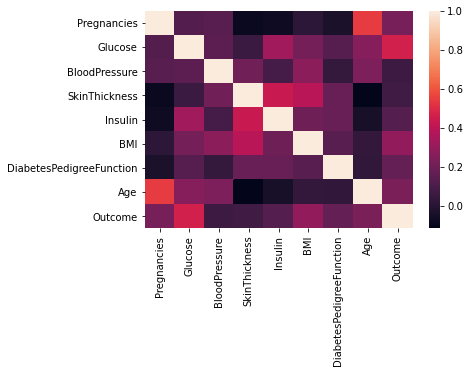

In [7]:
sns.heatmap(df.corr())

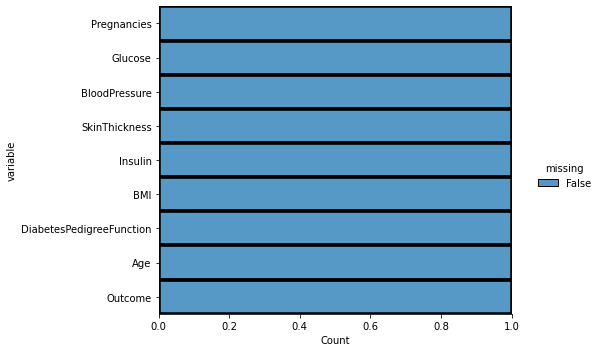

In [8]:
sns.displot(
data=df.isna().melt(value_name="missing"),# Convert missing values to long format
y="variable",# Plot missing values along the y-axis
hue="missing",# Differentiate missing and non-missing values with color
multiple="fill",
aspect=1.5
)
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
features = df.drop(columns=['Outcome'])
labels = df['Outcome']
# Dividing the data into training-test set with 80:20 split ratio
x_train,x_test,y_train,y_test = train_test_split(
features,labels,test_size=0.2,random_state=123)

In [12]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=2000, max_depth=30, random_state=123).fit(x_train, y_train)

In [13]:
model.score(x_test, y_test)

0.36647604184626437

## Feature Importance

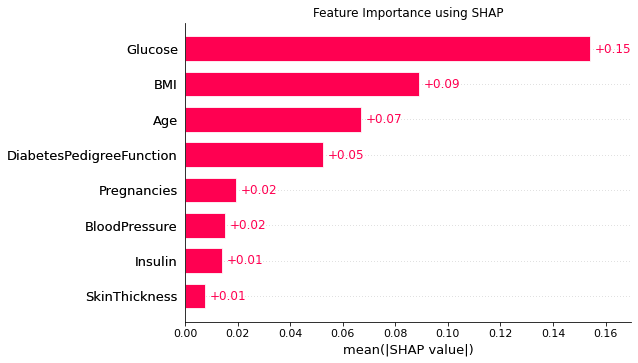

In [14]:
explainer = shap.Explainer(model)
shap_values = explainer(x_test)
plt.title('Feature Importance using SHAP')
shap.plots.bar(shap_values, show=True, max_display=12)

## descision plot

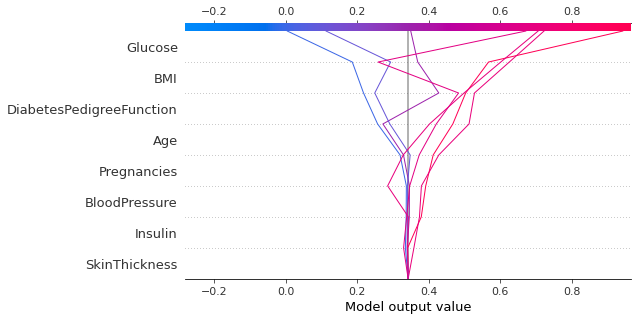

In [30]:
expected_value = explainer.expected_value
shap_values = explainer.shap_values(x_test[:7])
plt.figure(figsize=(10,15))
shap.decision_plot(expected_value, shap_values, x_test)
plt.show()

In [31]:
%%time
# Building a SHAP Explainer model
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(features)

Wall time: 20.4 s


## Summary plot

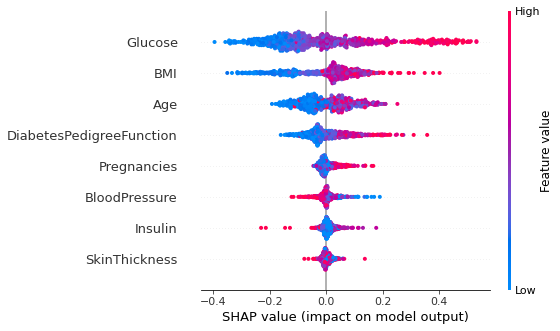

In [32]:
# Global explainability with summary plots
shap.summary_plot(shap_values, features)

## Feature dependency plot

Type of data: <class 'pandas.core.frame.DataFrame'>
Columns of data: Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')
Feature Dependence plot for: Pregnancies


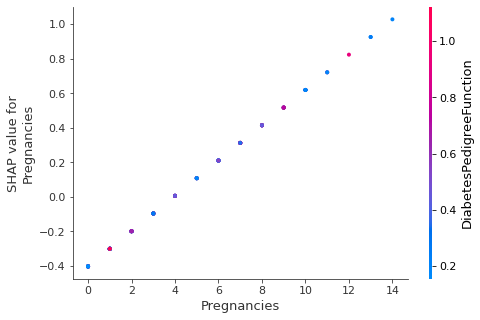

Feature Dependence plot for: Glucose


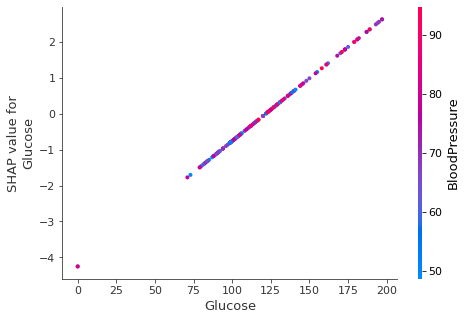

Feature Dependence plot for: BloodPressure


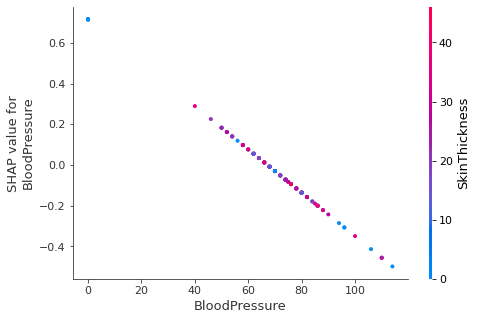

Feature Dependence plot for: SkinThickness


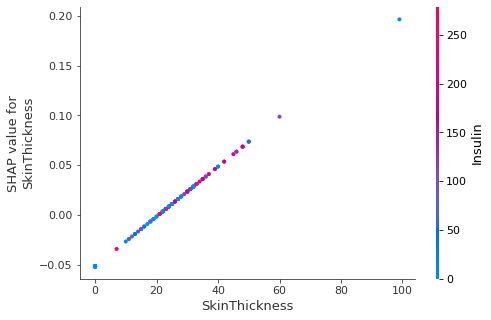

Feature Dependence plot for: Insulin


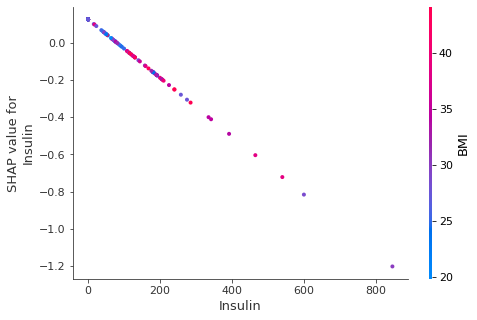

Feature Dependence plot for: BMI


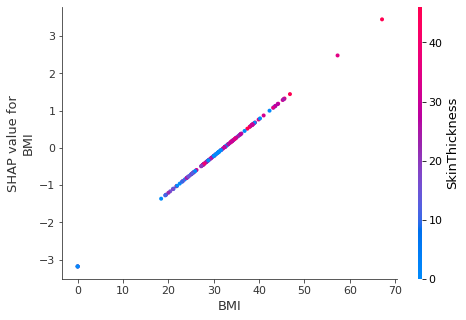

Feature Dependence plot for: DiabetesPedigreeFunction


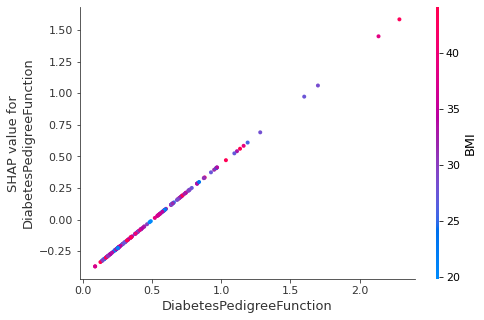

Feature Dependence plot for: Age


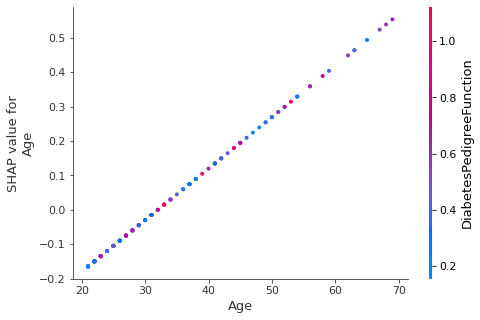

In [81]:
data = x_test.copy()

# Check the type and columns of `data`
print("Type of data:", type(data))
print("Columns of data:", data.columns)

# Loop through each feature and plot dependence plots
for col in data.columns:
    print(f"Feature Dependence plot for: {col}")
    shap.dependence_plot(
        col,  # Feature name
        shap_values_logistic.values,  # Full SHAP values array
        data,  # Feature data (input features)
        display_features=data  # Display features (optional)
    )

# Show the plots
plt.show()

In [52]:
type(data)

pandas.core.indexes.base.Index

## Force plot

In [60]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], features.iloc[0])

In [69]:
from sklearn.linear_model import LogisticRegression, LinearRegression
logistic = LogisticRegression()
linear = LinearRegression()

In [72]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score

# Linear Regression for predicting the probability of diabetes
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

# Making predictions and evaluating Linear Regression
y_pred_linear = linear_model.predict(x_test)
mse_linear = mean_squared_error(y_test, y_pred_linear)

print(f'Linear Regression Mean Squared Error: {mse_linear:.4f}')

# Logistic Regression for binary classification
logistic_model = LogisticRegression(max_iter=200)
logistic_model.fit(x_train, y_train)

# Making predictions and evaluating Logistic Regression
y_pred_logistic = logistic_model.predict(x_test)
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

print(f'Logistic Regression Accuracy: {accuracy_logistic:.4f}')

Linear Regression Mean Squared Error: 0.1541
Logistic Regression Accuracy: 0.8052


In [74]:
# SHAP values for Linear Regression
explainer_linear = shap.Explainer(linear_model, x_train)
shap_values_linear = explainer_linear(x_test)

In [75]:
# SHAP values for Logistic Regression
explainer_logistic = shap.Explainer(logistic_model, x_train)
shap_values_logistic = explainer_logistic(x_test)

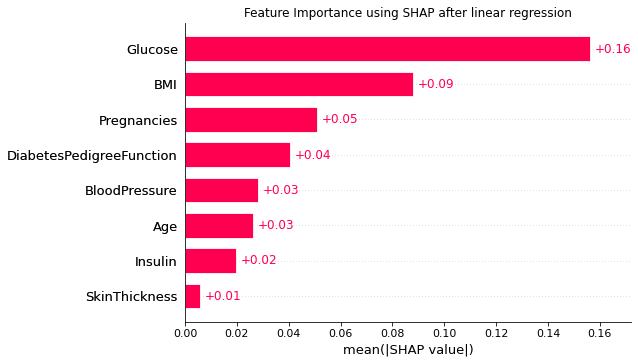

In [94]:
plt.title('Feature Importance using SHAP after linear regression')
shap.plots.bar(shap_values_linear, show=True, max_display=12)

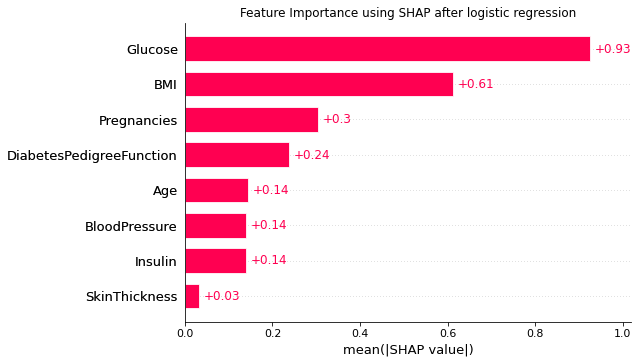

In [95]:
plt.title('Feature Importance using SHAP after logistic regression')
shap.plots.bar(shap_values_logistic, show=True, max_display=12)

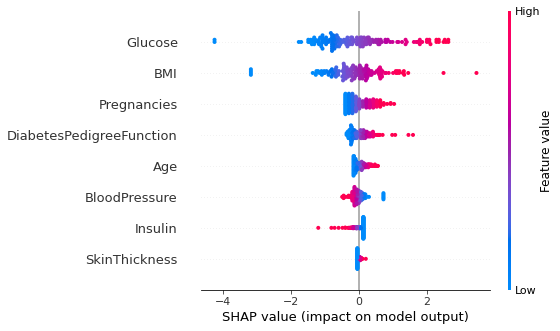

In [79]:
# Plot SHAP values for Logistic Regression
shap.initjs()
shap.summary_plot(shap_values_logistic, x_test, feature_names=features.columns)

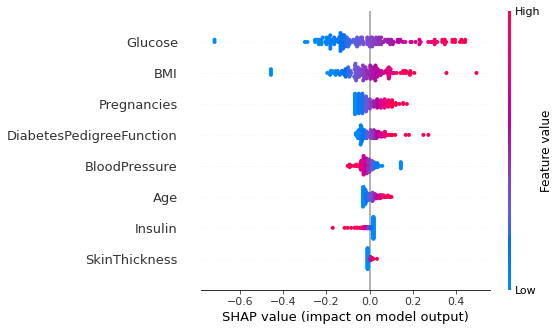

In [80]:
# Plot SHAP values for Logistic Regression
shap.initjs()
shap.summary_plot(shap_values_linear, x_test, feature_names=features.columns)

In [82]:
shap.initjs()
shap.force_plot(explainer_linear.expected_value, shap_values_linear.values[0], x_test.iloc[0])

In [84]:
shap.force_plot(explainer_logistic.expected_value, shap_values_logistic.values[0], x_test.iloc[0])

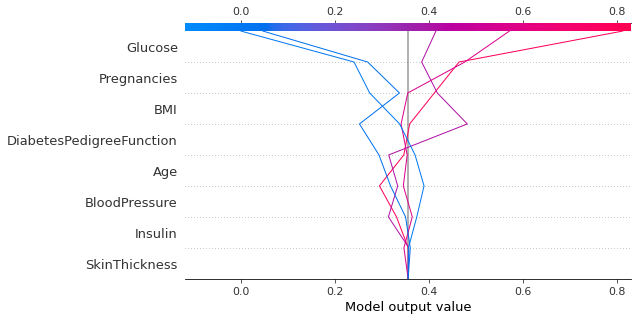

In [87]:
shap.decision_plot(explainer_linear.expected_value, shap_values_linear.values[:5], x_test.iloc[5])

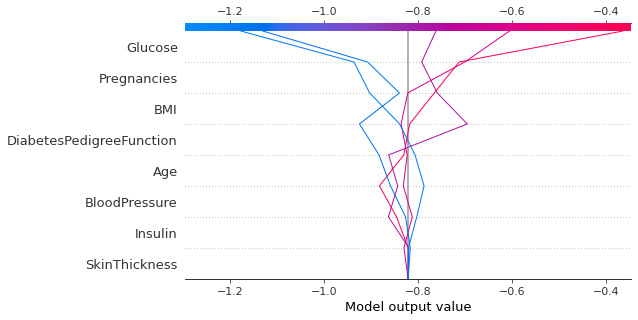

In [88]:
shap.decision_plot(explainer_logistic.expected_value, shap_values_linear.values[:5], x_test.iloc[5]) 